In [1]:
import socket
print(socket.gethostname())

awr-2-15


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from dask.distributed import Client
client = Client(n_workers=8, threads_per_worker=4)

print(client.dashboard_link)
print(client)

http://127.0.0.1:8787/status
<Client: 'tcp://127.0.0.1:39003' processes=8 threads=32, memory=64.00 GiB>


### ERA5 Pressure-Level Variables (3D)

| Variable Name | WWRF Equivalent Name | ERA5 Equivalent Name | Dimensions |
| --- | --- | --- | ---|
| **Geopotential** | `Z_e` | `geopotential` | (time, hybrid, latitude, longitude) |
| **Temperature** | `T_e` | `temperature` | (time, hybrid, latitude, longitude) |
| **Specific humidity** | `q_e` | `specific_humidity` | (time, hybrid, latitude, longitude) |
| **Zonal wind** | `u_gr_e` | `u_component_of_wind` | (time, hybrid, latitude, longitude) |
| **Meridional wind** | `v_gr_e` | `v_component_of_wind` | (time, hybrid, latitude, longitude) |

In [4]:
ds = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_native_vertical_grid_data = ds.sel(time=slice('2019-01-01T00:00:00.000000000', '2019-01-01T23:00:00.000000000'))

In [5]:
# 1. Define the variables we want to keep (using ERA5 names)
selected_vars = ["geopotential", "temperature", 
    "specific_humidity", "u_component_of_wind", "v_component_of_wind",
]

# 2. Select and Rename to match your desired shorthand
rename_map = {
    "geopotential": "Z_e",
    "temperature": "T_e",
    "specific_humidity": "q_e",
    "u_component_of_wind": "u_gr_e",
    "v_component_of_wind": "v_gr_e",
}

# Apply selection and renaming
ds_era5 = ar_native_vertical_grid_data[selected_vars].rename(rename_map)
ds_era5_resampled = ds_era5.resample(time='6h').mean()


ds_era5_resampled

<xarray.Dataset> Size: 11GB
Dimensions:    (time: 4, hybrid: 137, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T18:00:00
  * hybrid     (hybrid) float32 548B 1.0 2.0 3.0 4.0 ... 134.0 135.0 136.0 137.0
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    Z_e        (time, hybrid, latitude, longitude) float32 2GB 7.422e+05 ... ...
    T_e        (time, hybrid, latitude, longitude) float32 2GB 190.1 ... 244.5
    q_e        (time, hybrid, latitude, longitude) float32 2GB 1.289e-06 ... ...
    u_gr_e     (time, hybrid, latitude, longitude) float32 2GB -18.96 ... 4.135
    v_gr_e     (time, hybrid, latitude, longitude) float32 2GB 21.29 ... -1.139
Attributes:
    last_updated:      2026-03-18 07:47:33.081855+00:00
    valid_time_start:  1940-01-01
    valid_time_stop:   2025-12-31

### Vertical Coordinate Alignment

Following table shows the mapping based on the **pf (full-level pressure)** column from the L137 table:

| Target Pressure (hPa) | Closest Level | pf (hPa) |
|---|---|---|
| 50 | 48 | 49.60 |
| 100 | 60 | 98.42 |
| 150 | 68 | 147.91 |
| 200 | 74 | 197.37 |
| 250 | 79 | 248.36 |
| 300 | 83 | 296.52 |
| 400 | 90 | 398.85 |
| 500 | 96 | 507.50 |
| 600 | 100 | 589.68 |
| 700 | 105 | 693.30 |
| 850 | 114 | 849.77 |
| 925 | 120 | 920.92 |
| 1000 | 133 | 1000.52 |

**Note:** Most matches are quite close, level 114 for 850 hPa and level 133 for 1000 hPa are nearly exact (within ~0.5 hPa), while 600 hPa (level 100, off by ~10 hPa) is the least precise match.

In [6]:
# vertical_subset = [48, 60, 68, 74, 79, 83, 90, 96, 101, 105, 114, 120, 133]
vertical_subset = [48, 60, 68, 74, 79, 83, 90, 96, 98, 101, 103, 105, 108, 111, 114, 118, 120, 123, 133]
ds_era5_vsubset = ds_era5_resampled.sel(hybrid=vertical_subset, method='nearest')

In [7]:
# Convert ERA5 Geopotential (m^2/s^2) to Geopotential Height (m)
ds_era5_vsubset['Z_e'] = ds_era5_vsubset['Z_e'] / 9.80665
ds_era5_vsubset

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 4, hybrid: 19, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T18:00:00
  * hybrid     (hybrid) float32 76B 48.0 60.0 68.0 74.0 ... 120.0 123.0 133.0
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    Z_e        (time, hybrid, latitude, longitude) float32 316MB 1.958e+04 .....
    T_e        (time, hybrid, latitude, longitude) float32 316MB 220.6 ... 245.0
    q_e        (time, hybrid, latitude, longitude) float32 316MB 3.187e-06 .....
    u_gr_e     (time, hybrid, latitude, longitude) float32 316MB 7.342 ... 6.558
    v_gr_e     (time, hybrid, latitude, longitude) float32 316MB 17.8 ... -0....
Attributes:
    last_updated:      2026-03-18 07:47:33.081855+00:00
    valid_time_start:  1940-01-01
    valid_time_stop:   2025-12-31

### WWRF Pressure-Level Variables (3D)

In [8]:
save_path = '/cw3e/mead/projects/cwp167/moerfani_data/regional/2019/01M/wwrf_reanalysis_modellev_d01_2019-01-01-v2.nc'
ds_wwrf = xr.open_mfdataset(save_path, engine='h5netcdf', data_vars='all')
ds_wwrf = ds_wwrf[['Z_e', 'T_e', 'q_e', 'u_gr_e', 'v_gr_e', 'p_e']]

### The Problem with the Old Formula
The original script calculated target $\eta$ (eta) levels like this:
$$\eta = \frac{P_{target}}{P_{sfc}}$$
This is the traditional sigma coordinate equation *only* when the top of the model is an absolute vacuum ($P_{top} = 0$). For WRF, the traditional terrain-following hydrostatic pressure coordinate is actually defined as:
$$\eta = \frac{P - P_{top}}{P_{sfc} - P_{top}}$$

If we look at your 50 hPa target with $P_{top} = 10$ hPa, the correct target $\eta$ is roughly **0.0398**. Your old script was targeting **0.0493**. In the upper atmosphere, that error is large enough to make you select the wrong vertical index, which will skew your comparison with the ERA5 levels.

### The Hybrid Coordinate Shortcut
We found the exact formula WRF uses for its newer hybrid sigma-pressure vertical coordinates:
$$P_{dry}(i,j,k) = B(k)(P_{sfc}(i,j) - P_{top}) + (\eta(k) - B(k))(P_0 - P_{top}) + P_{top}$$

At first glance, this looks like we need to extract the $B(k)$ weighting array from WRF files just to get a nominal 1D pressure estimate. However, because we are calculating a *nominal* 1D profile based on a standard reference surface pressure ($P_{sfc} = P_0 = 1013.25$ hPa), a really neat mathematical cancellation happens. 

If we set $P_{sfc} = P_0$, the equation simplifies:
$$P_{dry} = B(k)(P_0 - P_{top}) + \eta(k)(P_0 - P_{top}) - B(k)(P_0 - P_{top}) + P_{top}$$
$$P_{dry} = \eta(k)(P_0 - P_{top}) + P_{top}$$

**The $B(k)$ terms completely cancel out.** This means for a standard 1D nominal column over the ocean or flat ground (where surface pressure equals the reference pressure), the hybrid coordinate behaves *exactly* like the traditional terrain-following $\eta$ coordinate. The hybrid coordinate only deviates from this formula over topography where actual surface pressure diverges from $P_0$.


In [9]:
# Your provided array of 99 eta levels
eta_levels = np.array([
    9.9804688e-01, 9.9316406e-01, 9.8730469e-01, 9.8242188e-01,
    9.7656250e-01, 9.6972656e-01, 9.6386719e-01, 9.5703125e-01,
    9.4921875e-01, 9.4140625e-01, 9.3359375e-01, 9.2480469e-01,
    9.1601562e-01, 9.0722656e-01, 8.9746094e-01, 8.8671875e-01,
    8.7597656e-01, 8.6425781e-01, 8.5253906e-01, 8.4082031e-01,
    8.2812500e-01, 8.1445312e-01, 8.0078125e-01, 7.8613281e-01,
    7.7148438e-01, 7.5585938e-01, 7.4023438e-01, 7.2460938e-01,
    7.0800781e-01, 6.9042969e-01, 6.7285156e-01, 6.5527344e-01,
    6.3769531e-01, 6.1914062e-01, 6.0058594e-01, 5.8203125e-01,
    5.6250000e-01, 5.4394531e-01, 5.2441406e-01, 5.0585938e-01,
    4.8632812e-01, 4.6777344e-01, 4.4824219e-01, 4.2968750e-01,
    4.1113281e-01, 3.9257812e-01, 3.7500000e-01, 3.5742188e-01,
    3.3984375e-01, 3.2324219e-01, 3.0664062e-01, 2.9101562e-01,
    2.7539062e-01, 2.6074219e-01, 2.4609375e-01, 2.3242188e-01,
    2.1875000e-01, 2.0605469e-01, 1.9335938e-01, 1.8164062e-01,
    1.7089844e-01, 1.6015625e-01, 1.4941406e-01, 1.3964844e-01,
    1.3085938e-01, 1.2207031e-01, 1.1328125e-01, 1.0546875e-01,
    9.7534180e-02, 9.0332031e-02, 8.3557129e-02, 7.7087402e-02,
    7.0983887e-02, 6.5246582e-02, 5.9875488e-02, 5.4748535e-02,
    4.9926758e-02, 4.5471191e-02, 4.1259766e-02, 3.7353516e-02,
    3.3691406e-02, 3.0395508e-02, 2.7282715e-02, 2.4414062e-02,
    2.1789551e-02, 1.9348145e-02, 1.7150879e-02, 1.5075684e-02,
    1.3122559e-02, 1.1352539e-02, 9.7274780e-03, 8.2168579e-03,
    6.8206787e-03, 5.5313110e-03, 4.3411255e-03, 3.2424927e-03,
    2.2201538e-03, 1.2817383e-03, 4.1675568e-04
])

# The exact target levels from the manuscript excerpt
# target_pressures_hpa = np.array([50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000])
target_pressures_hpa = np.array([50, 100, 150, 200, 250, 300, 400, 500, 550, 600, 650, 700, 750, 800, 850, 900, 925, 950, 1000])

# Define reference pressures
P_sfc = 1013.25 # hPa (or P0 reference pressure)
P_top = 10.0    # hPa (WRF model top)

# Correct formula accounting for P_top
# Eta_target = (P_target - P_top) / (P_sfc - P_top)
target_etas = (target_pressures_hpa - P_top) / (P_sfc - P_top)

# Find the index of the nearest eta value for each target
nearest_indices = [np.abs(eta_levels - target).argmin() for target in target_etas]
matched_etas = eta_levels[nearest_indices]

# Print the correspondence mapping
print(f"Index Selection Based on P_sfc = {P_sfc} hPa and P_top = {P_top} hPa:\n")
for p, eta, idx in zip(target_pressures_hpa, matched_etas, nearest_indices):
    # Re-calculate the nominal pressure from the matched eta level to see the accuracy
    nominal_p = (eta * (P_sfc - P_top)) + P_top
    print(f"Target: {p:>4} hPa -> Extract Index: {idx:>2} | (Eta: {eta:.6f}, Nominal P: {nominal_p:>6.2f} hPa)")

Index Selection Based on P_sfc = 1013.25 hPa and P_top = 10.0 hPa:

Target:   50 hPa -> Extract Index: 78 | (Eta: 0.041260, Nominal P:  51.39 hPa)
Target:  100 hPa -> Extract Index: 69 | (Eta: 0.090332, Nominal P: 100.63 hPa)
Target:  150 hPa -> Extract Index: 63 | (Eta: 0.139648, Nominal P: 150.10 hPa)
Target:  200 hPa -> Extract Index: 58 | (Eta: 0.193359, Nominal P: 203.99 hPa)
Target:  250 hPa -> Extract Index: 55 | (Eta: 0.232422, Nominal P: 243.18 hPa)
Target:  300 hPa -> Extract Index: 51 | (Eta: 0.291016, Nominal P: 301.96 hPa)
Target:  400 hPa -> Extract Index: 45 | (Eta: 0.392578, Nominal P: 403.85 hPa)
Target:  500 hPa -> Extract Index: 40 | (Eta: 0.486328, Nominal P: 497.91 hPa)
Target:  550 hPa -> Extract Index: 37 | (Eta: 0.543945, Nominal P: 555.71 hPa)
Target:  600 hPa -> Extract Index: 35 | (Eta: 0.582031, Nominal P: 593.92 hPa)
Target:  650 hPa -> Extract Index: 32 | (Eta: 0.637695, Nominal P: 649.77 hPa)
Target:  700 hPa -> Extract Index: 29 | (Eta: 0.690430, Nominal

In [10]:
ds_wwrf_vsubset = ds_wwrf.isel(eta=nearest_indices)
ds_wwrf_vsubset

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 4, eta: 19, south_north: 970, west_east: 1389)
Coordinates:
  * time         (time) datetime64[ns] 32B 2019-01-01 ... 2019-01-01T18:00:00
  * eta          (eta) float32 76B 0.04126 0.09033 0.1396 ... 0.9336 0.9873
  * south_north  (south_north) float32 4kB -2.827e+03 -2.821e+03 ... 2.988e+03
  * west_east    (west_east) float32 6kB -5.238e+03 -5.232e+03 ... 3.091e+03
    lat          (south_north, west_east) float32 5MB dask.array<chunksize=(970, 1389), meta=np.ndarray>
    lon          (south_north, west_east) float32 5MB dask.array<chunksize=(970, 1389), meta=np.ndarray>
Data variables:
    Z_e          (time, eta, south_north, west_east) float32 410MB dask.array<chunksize=(4, 19, 970, 1389), meta=np.ndarray>
    T_e          (time, eta, south_north, west_east) float32 410MB dask.array<chunksize=(4, 19, 970, 1389), meta=np.ndarray>
    q_e          (time, eta, south_north, west_east) float32 410MB dask.array<chunksize=(4, 19, 970, 1389), meta=np.ndarray>
    u_gr_e       (time, eta, south_north, west_east) float32 410MB dask.array<chunksize=(4, 19, 970, 1389), meta=np.ndarray>
    v_gr_e       (time, eta, south_north, west_east) float32 410MB dask.array<chunksize=(4, 19, 970, 1389), meta=np.ndarray>
    p_e          (time, eta, south_north, west_east) float32 410MB dask.array<chunksize=(4, 19, 970, 1389), meta=np.ndarray>
Attributes:
    CDI:            Climate Data Interface version 2.4.4 (https://mpimet.mpg....
    Conventions:    CF 1.6, Standard Name Table v19
    source:         /cw3e/mead/projects/cnt117/reanalysis_temp/input/2018/d01...
    institution:    CW3E - Scripps Institution of Oceanography
    title:          /cw3e/mead/projects/cnt117/reanalysis_temp/output/2018/d0...
    notes:          Created with NCL script:  wrfout_to_cf.ncl v2.0
    created_by:     Daniel Steinhoff - dsteinhoff@ucsd.edu
    creation_date:  Fri Dec  5 01:18:13 PM PST 2025
    history:        Fri Dec  5 13:24:15 2025: /home/cw3eprod/miniforge3/envs/...
    CDO:            Climate Data Operators version 2.4.4 (https://mpimet.mpg....
    NCO:            netCDF Operators version 5.2.9 (Homepage = http://nco.sf....

### Extracting a Regional Subset from ERA5 Data
This code extracts a region of interest (ROI) from the ERA5 dataset that spatially matches the WRF model domain. Here's what it does:

### Step 1: Longitude Format Conversion
Converts WRF longitudes from the `[-180, 180]` range to `[0, 360]` space. This is necessary because:
- WRF typically uses negative longitudes for the Western Hemisphere (e.g., -120° for California)
- ERA5 uses positive longitudes throughout `[0, 360]`
- The modulo operation `% 360` ensures all values stay within the valid range

This temporary conversion makes it easier to find the correct bounding box without dealing with the discontinuity at the ±180° meridian.

### Step 2: Calculate Bounding Box
Extracts the spatial extent of the WRF domain:
- **min/max longitude**: Western and eastern boundaries (in 0–360 space)
- **min/max latitude**: Southern and northern boundaries

ROI has bounds like `Lon 157.37 to 289.98, Lat 5.76 to 67.13`.

### Step 3: Extract ERA5 Region of Interest
Selects the matching spatial region from ERA5 using xarray's `.sel()` method. Note the important details:

- **Latitude slice**: `(max_lat + buffer, min_lat - buffer)` — ERA5 latitudes descend from north to south, so the bounds are reversed compared to what you might expect
- **Longitude slice**: `(min_lon - buffer, max_lon + buffer)` — ERA5 longitudes are in ascending order (0–360), matching the coordinate space we converted to

This ensures perfect spatial alignment between the WRF and ERA5 subsets for comparison.

In [11]:
# 1. Convert WRF 2D longitudes to [0, 360] space temporarily for the bounding box
wrf_lon_360 = (ds_wwrf_vsubset.lon + 360) % 360

# 2. Calculate the true bounding box in 0-360 space
min_lon = wrf_lon_360.min().values
max_lon = wrf_lon_360.max().values

min_lat = ds_wwrf_vsubset.lat.min().values
max_lat = ds_wwrf_vsubset.lat.max().values

# Just to verify, this should now print a much narrower, correct range (e.g., 220 to 250)
print(f"Corrected WRF Bounds: Lon {min_lon:.2f} to {max_lon:.2f}, Lat {min_lat:.2f} to {max_lat:.2f}")

buffer = 0.0 # degrees

# 3. Slice the NATIVE ERA5 dataset (do NOT shift ERA5 to -180/180 beforehand)
ds_era5_vsubset = ds_era5_vsubset.sel(
    latitude=slice(max_lat + buffer, min_lat - buffer),   # Remember: ERA5 lats are descending!
    longitude=slice(min_lon - buffer, max_lon + buffer)   # Ascending order
)

Corrected WRF Bounds: Lon 157.37 to 289.98, Lat 5.76 to 67.13


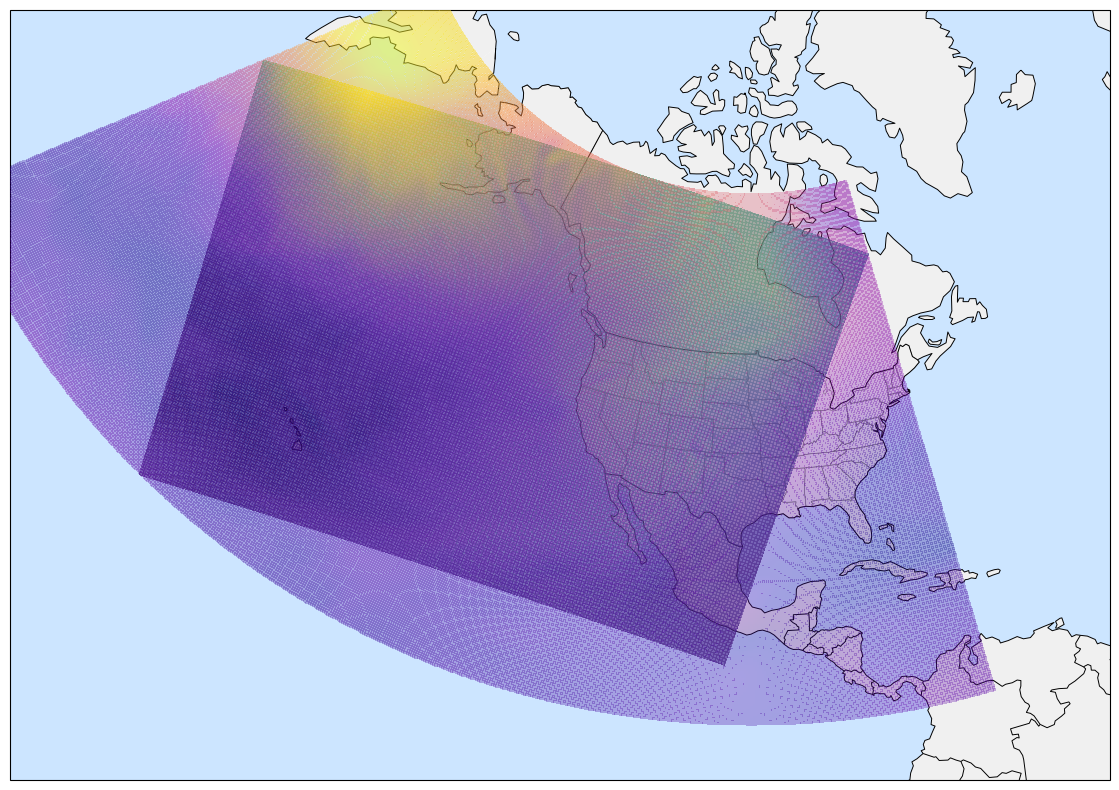

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.LambertConformal(central_longitude=-96, central_latitude=39)

fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": proj})

# ── 1. Basemap ───────────────────────────────────────────────────
ax.set_extent([-180, -60, 0, 75], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      facecolor="#f0f0f0")
ax.add_feature(cfeature.OCEAN,     facecolor="#cce5ff")
ax.add_feature(cfeature.STATES,    linewidth=0.4, edgecolor="gray")
ax.add_feature(cfeature.BORDERS,   linewidth=0.7, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

# ── 2. Extract data + 2D lat/lon ─────────────────────────────────
data2 = ds_era5_vsubset.T_e.isel(hybrid=0, time=0)
lat2  = ds_era5_vsubset.latitude.values
lon2  = ds_era5_vsubset.longitude.values

mesh2 = ax.pcolormesh(
    lon2, lat2, data2.squeeze().values,
    transform=ccrs.PlateCarree(),
    cmap="plasma",
    shading='auto',
    zorder=4,
    alpha=0.3
)

data1 = ds_wwrf_vsubset.T_e.isel(eta=0, time=0)
lat1  = ds_wwrf_vsubset.lat.values   # shape (south_north, west_east)
lon1  = ds_wwrf_vsubset.lon.values

# ── 3. Overlay with pcolormesh using explicit lat/lon ────────────
mesh1 = ax.pcolormesh(
    lon1, lat1, data1.squeeze().values,   # squeeze drops the size-1 extra dim
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    shading='auto',                    # handles non-staggered grids cleanly
    zorder=3,
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_comparison(era5_ds, wrf_ds, variables=None, target_pressures_hpa=None):
    # Defaults
    if target_pressures_hpa is None:
        # target_pressures_hpa = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
        target_pressures_hpa = [50, 100, 150, 200, 250, 300, 400, 500, 550, 600, 650, 700, 750, 800, 850, 900, 925, 950, 1000]
        
    if variables is None:
        variables = ['Z_e', 'T_e', 'q_e', 'u_gr_e', 'v_gr_e']
        
    # Simple metadata for plot labels
    meta = {
        'Z_e': ('Geopotential Height', 'm'),
        'T_e': ('Temperature', 'K'),
        'q_e': ('Specific humidity', 'kg/kg'),
        'u_gr_e': ('Zonal wind', 'm/s'),
        'v_gr_e': ('Meridional wind', 'm/s'),
    }

    # Setup grid layout
    n_vars = len(variables)
    n_cols = min(3, n_vars)  
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(5*n_cols, 5*n_rows), constrained_layout=True)
    axes = np.array(axes).flatten() if n_vars > 1 else [axes]

    # Calculate ERA5 weights once
    era_weights = np.cos(np.deg2rad(era5_ds.latitude))

    for i, var in enumerate(variables):
        ax = axes[i]
        title, units = meta.get(var, (var, ''))
        
        # 1. ERA5: Weighted spatial mean
        era_avg = era5_ds[var].weighted(era_weights).mean(dim=("latitude", "longitude", "time"))
        
        # 2. WRF: Standard spatial mean
        wrf_avg = wrf_ds[var].mean(dim=("south_north", "west_east", "time"))

        # 3. Plotting
        ax.plot(era_avg, target_pressures_hpa, label='ERA5', 
                color='blue', marker='o', markersize=6, linewidth=2)
        ax.plot(wrf_avg, target_pressures_hpa, label='WRF', 
                color='red', marker='x', markersize=8, linewidth=2, linestyle='--')

        # 4. Formatting
        ax.set_title(title, fontsize=14)
        ax.set_xlabel(units, fontsize=12)
        ax.set_ylabel('Pressure (hPa)', fontsize=12)
        
        # Format Log-Pressure Y-axis
        ax.set_ylim(max(target_pressures_hpa) + 25, min(target_pressures_hpa) - 10)
        ax.set_yscale('log')
        ax.set_yticks(target_pressures_hpa)
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

        # Scientific notation for large numbers (like Geopotential)
        if 'Z' in var:
            ax.ticklabel_format(style='sci', axis='x', scilimits=(3, 3), useMathText=True)

        ax.grid(True, alpha=0.4, which='both')
        ax.legend()

    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.show()

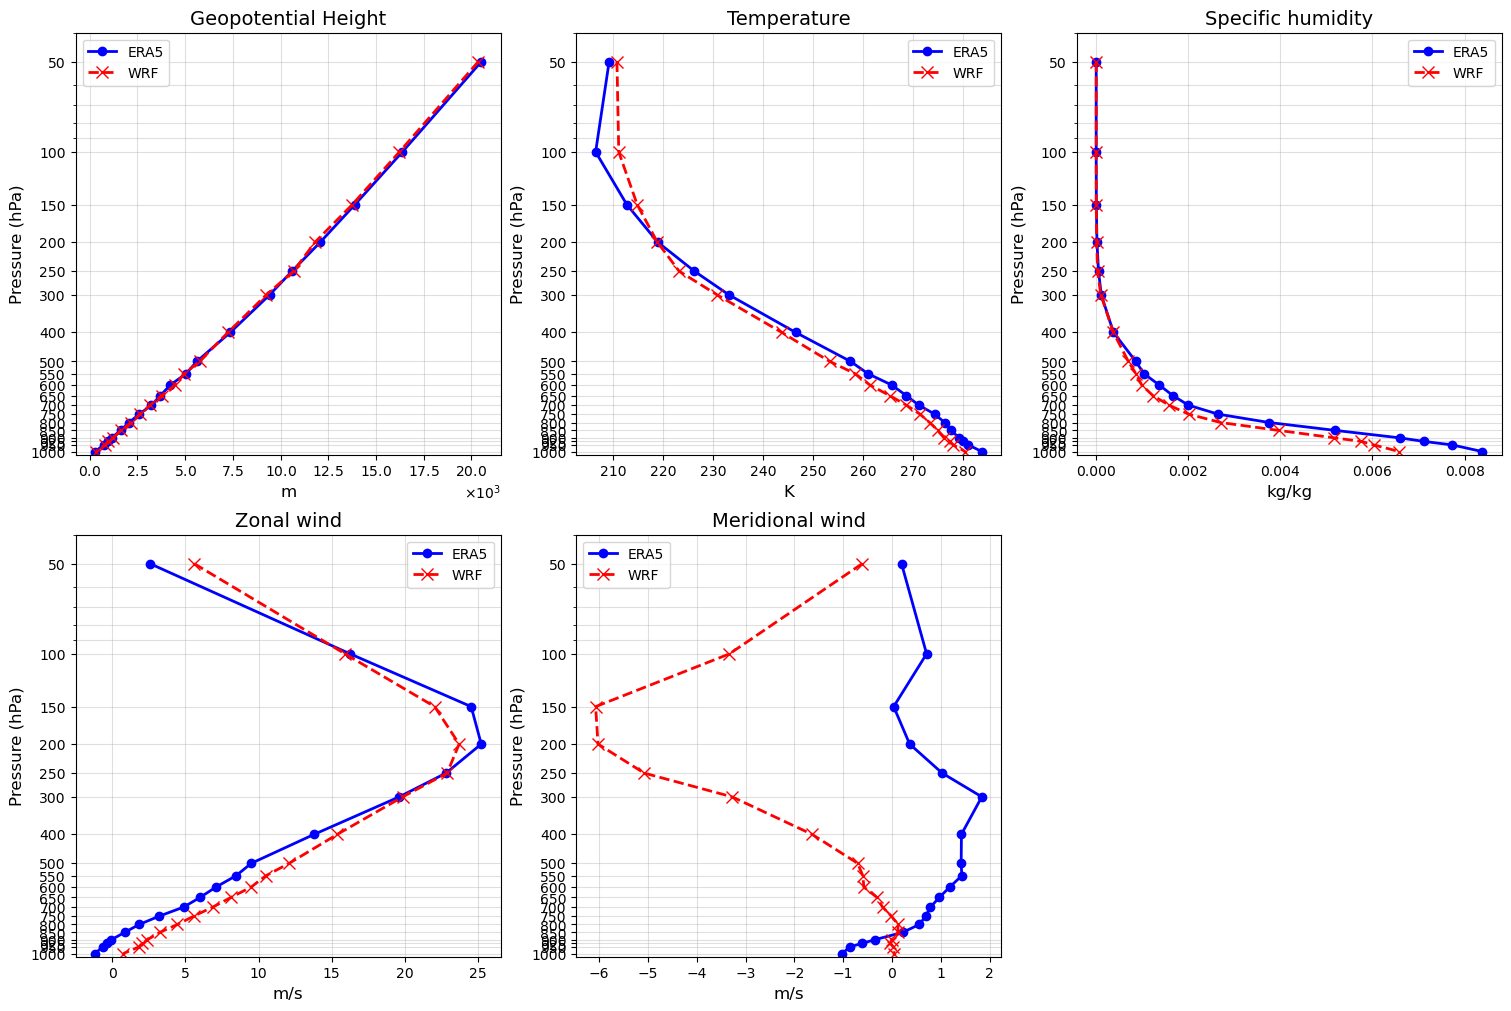

In [15]:
# Example usage:
plot_model_comparison(ds_era5_vsubset, ds_wwrf_vsubset)

While Zonal (U) wind matches fairly well, the Meridional (V) wind is completely reversed and amplified. This is the classic signature of a **grid rotation issue**. 

### The Problem: Grid-Relative vs. Earth-Relative Winds
When you download ERA5 data, the `u` and `v` wind components are always **Earth-relative**. `u` points exactly true East, and `v` points exactly true North, no matter where you are on the globe.

WRF, however, calculates its physics on a computational grid. Because your WRF domain uses a Lambert Conformal projection, the grid is essentially a cone flattened onto a map. In the raw `wrfout` files, the `U` and `V` variables are **grid-relative**. They align with the WRF x-axis and y-axis. 
* Grid "North" (the +Y direction) only perfectly aligns with True North at the exact central longitude of your WRF domain. 
* Everywhere else, the grid is tilted relative to the Earth's meridians. 

### Why it ruins the V-wind but not the U-wind
Take a look at the magnitudes on your plots. Your Zonal wind is blowing fast (around 25 m/s at its peak). Your actual Earth-relative Meridional wind (ERA5) is very weak (only 1 to 2 m/s). 

If your region of interest is far from the center of the WRF domain, the grid might be tilted by, say, 10 to 15 degrees. Because the grid is tilted, a massive chunk of that strong 25 m/s Zonal wind "bleeds" into the computational V-wind axis. 

Mathematically, if the true wind is almost entirely blowing East, but your grid is tilted slightly clockwise, the wind will appear to be blowing "down" (negative Y) relative to the grid. 
* Subtracting a few m/s from a 25 m/s Zonal wind barely changes the shape of the U plot. 
* Adding -5 m/s to a weak 1 m/s Meridional wind completely flips the sign and ruins the V plot.

### How to Fix It
To compare WRF winds to ERA5 winds, you must **rotate the WRF winds back to Earth-relative coordinates** (often called "earth-relative" or "meteorological" winds) before doing any spatial averaging.

You would first destagger the winds to the mass points, and then apply the rotation matrix:
```python
# Assuming u_destag and v_destag are already interpolated to the mass points
u_earth = u_destag * ds['COSALPHA'] - v_destag * ds['SINALPHA']
v_earth = v_destag * ds['COSALPHA'] + u_destag * ds['SINALPHA']
```

Once you plot `u_earth` and `v_earth` (or whatever variable names you assign them), that massive gap in the Meridional wind will vanish, and the curves will align much like your Temperature and Specific Humidity plots do.

In [16]:
sincos = xr.open_dataset('sincos.nc', chunks='auto')
sincos

<xarray.Dataset> Size: 21MB
Dimensions:   (time: 1, y: 960, x: 1379)
Coordinates:
  * time      (time) datetime64[ns] 8B 2020-01-04
  * y         (y) float64 8kB 5.0 6.0 7.0 8.0 9.0 ... 961.0 962.0 963.0 964.0
  * x         (x) float64 11kB 5.0 6.0 7.0 8.0 ... 1.381e+03 1.382e+03 1.383e+03
    lon       (y, x) float32 5MB dask.array<chunksize=(960, 1379), meta=np.ndarray>
    lat       (y, x) float32 5MB dask.array<chunksize=(960, 1379), meta=np.ndarray>
Data variables:
    SinAlpha  (time, y, x) float32 5MB dask.array<chunksize=(1, 960, 1379), meta=np.ndarray>
    CosAlpha  (time, y, x) float32 5MB dask.array<chunksize=(1, 960, 1379), meta=np.ndarray>
Attributes:
    CDI:            Climate Data Interface version 2.5.0 (https://mpimet.mpg....
    Conventions:    CF-1.6
    source:         /cw3e/mead/projects/cnt117/reanalysis_temp/input/2019/d01...
    institution:    CW3E - Scripps Institution of Oceanography
    title:          test.nc
    notes:          Created with wrfout_to_cf.py
    created_by:     Daniel Steinhoff - dsteinhoff@ucsd.edu
    creation_date:  Fri Nov 21 07:21:21 2025
    history:        Fri Nov 21 07:35:19 2025: cdo selname,CosAlpha,SinAlpha t...
    CDO:            Climate Data Operators version 2.5.0 (https://mpimet.mpg....

### WRF' Lateral Boundary Conditions 

Here is exactly what happened:
Notice how the WRF file is exactly **10 grid points larger** in both dimensions? 
* `970 - 960 = 10` (south_north)
* `1389 - 1379 = 10` (west_east)

In WRF, the outer edges of the domain are used as a "relaxation zone" (or sponge layer) to blend the regional model with the global boundary conditions. By default, this boundary zone is exactly **5 grid cells wide**. 

Whoever (or whatever script) generated that `sincos.nc` file clipped off those 5 useless boundary points on all four sides ($5 + 5 = 10$) to save space and keep only the usable physics data. Your WRF file still has the raw boundaries attached.

In [17]:
sincos_lon_360 = (sincos.lon + 360) % 360

# 2. Calculate the true bounding box in 0-360 space
min_lon = sincos_lon_360.min().values
max_lon = sincos_lon_360.max().values

min_lat = sincos.lat.min().values
max_lat = sincos.lat.max().values

# Just to verify, this should now print a much narrower, correct range (e.g., 220 to 250)
print(f"Corrected WRF Bounds: Lon {min_lon:.2f} to {max_lon:.2f}, Lat {min_lat:.2f} to {max_lat:.2f}")

Corrected WRF Bounds: Lon 157.92 to 289.28, Lat 6.07 to 66.89


In [18]:
# The standard boundary width in WRF is 5 points
bdy = 5

# Crop 5 points off every edge
ds_wwrf_cropped = ds_wwrf_vsubset.isel(
    south_north=slice(bdy, -bdy),
    west_east=slice(bdy, -bdy)
)

print("Cropped Dimensions:")
print(f"south_north: {ds_wwrf_cropped.sizes['south_north']} (Target: 960)")
print(f"west_east: {ds_wwrf_cropped.sizes['west_east']} (Target: 1379)")

Cropped Dimensions:
south_north: 960 (Target: 960)
west_east: 1379 (Target: 1379)


In [19]:
# 1. Convert WRF 2D longitudes to [0, 360] space temporarily for the bounding box
wrf_cropped_lon_360 = (ds_wwrf_cropped.lon + 360) % 360

# 2. Calculate the true bounding box in 0-360 space
min_lon = wrf_cropped_lon_360.min().values
max_lon = wrf_cropped_lon_360.max().values

min_lat = ds_wwrf_cropped.lat.min().values
max_lat = ds_wwrf_cropped.lat.max().values

# Just to verify, this should now print a much narrower, correct range (e.g., 220 to 250)
print(f"Corrected WRF Bounds: Lon {min_lon:.2f} to {max_lon:.2f}, Lat {min_lat:.2f} to {max_lat:.2f}")

Corrected WRF Bounds: Lon 157.92 to 289.28, Lat 6.07 to 66.89


In [20]:
# Rename the sincos dimensions to match WRF exactly
sincos_aligned = sincos.rename({'y': 'south_north', 'x': 'west_east'})

# Extract the 2D arrays
cos_alpha = sincos['CosAlpha'].isel(time=0).data
sin_alpha = sincos['SinAlpha'].isel(time=0).data

# Now Xarray knows they share the exact same spatial grid and will broadcast cleanly over time and level!
u_earth = ds_wwrf_cropped['u_gr_e'] * cos_alpha - ds_wwrf_cropped['v_gr_e'] * sin_alpha
v_earth = ds_wwrf_cropped['v_gr_e'] * cos_alpha + ds_wwrf_cropped['u_gr_e'] * sin_alpha

ds_wwrf_cropped['u_gr_e'] = u_earth
ds_wwrf_cropped['v_gr_e'] = v_earth

### The Winds are now Earth-Relative

* **The massive gap is gone:** Previously, your WRF V-wind was wildly skewed. Now, it is constrained to the correct physical magnitude (-1.5 to +2.0 m/s). 
* **Remaining differences are normal:** While the V-wind isn't a perfect 1:1 match like the Zonal wind, **this is exactly what you should expect.** Meridional wind is highly sensitive to regional topography, boundary layer physics, and local thermal forcing (like land-sea breezes or mountain valley flows). ERA5 is a smoothed, global reanalysis grid, while your WRF model is running at a higher regional resolution and generating its own local weather patterns. A deviation of 1-3 m/s in the V-component is very standard for a regional downscaling run.
* **Zonal (U) wind is excellent:** Both models perfectly capture the core of the jet stream sitting around 200 hPa (peaking at ~25 m/s). 

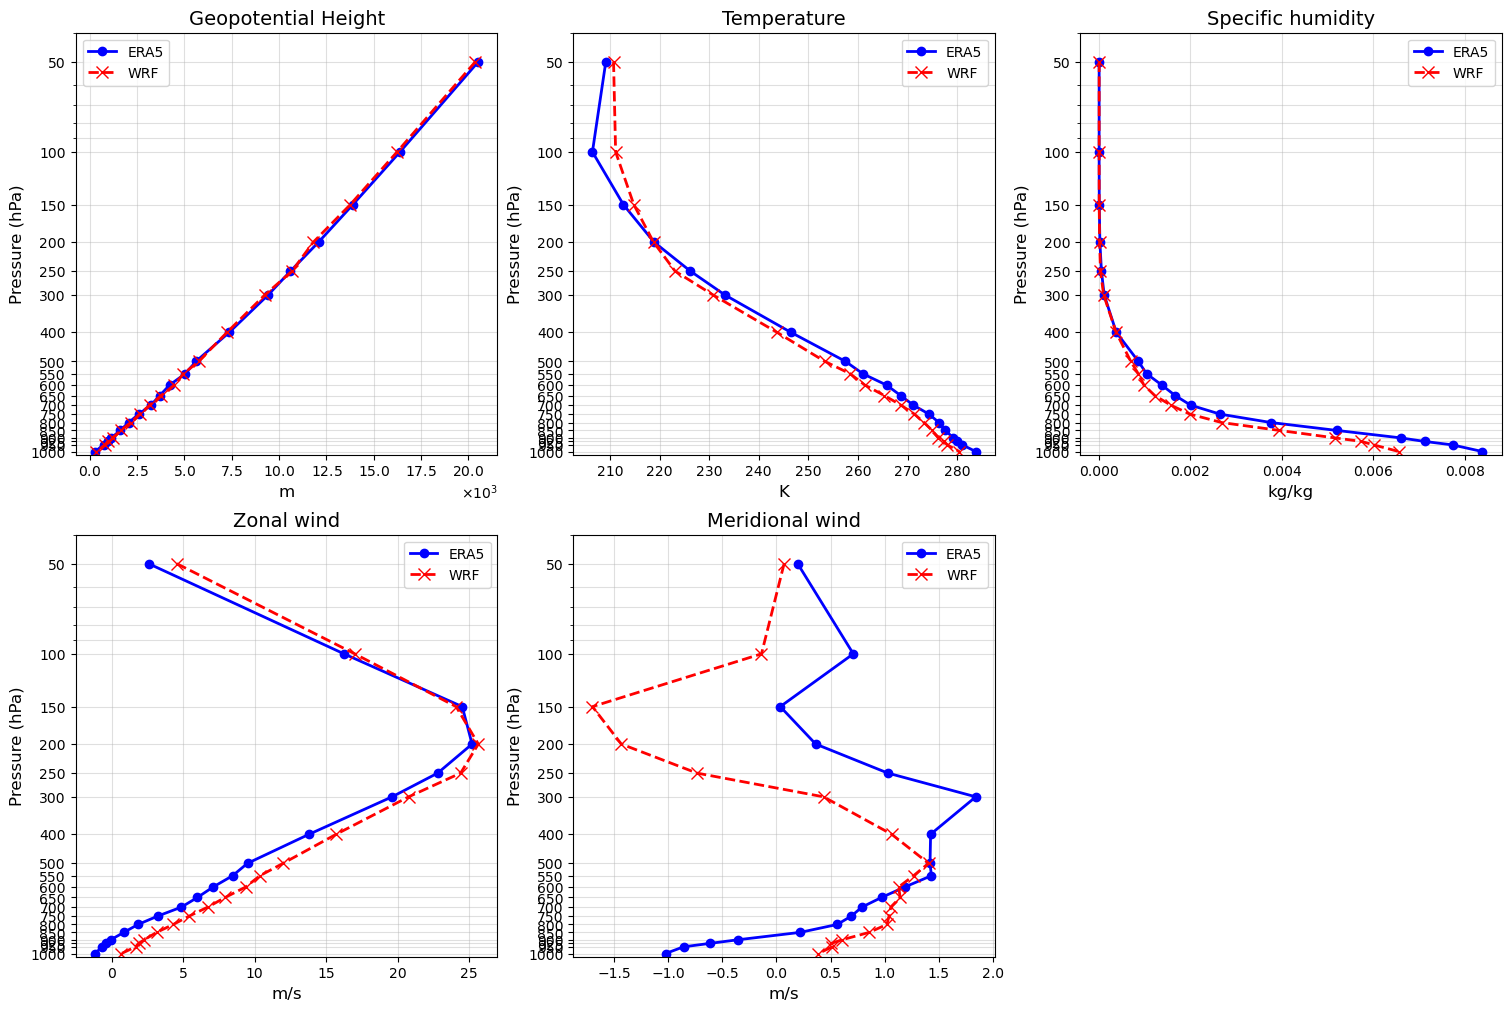

In [21]:
plot_model_comparison(ds_era5_vsubset, ds_wwrf_cropped)

### Comparison of Target Pressure vs. ECMWF (ERA5) & WRF (Corresponding pressure) Levels

| Target Pressure (hPa) | ECMWF L137 Index | WRF Eta Index (Value) | ECMWF $pf$ (hPa) | WRF Nominal P (hPa) |
| :--- | :--- | :--- | :--- | :--- |
| **50** | 48 | 78 (0.041260) | 49.60 | 51.39 |
| **100** | 60 | 69 (0.090332) | 98.42 | 100.63 |
| **150** | 68 | 63 (0.139648) | 147.91 | 150.10 |
| **200** | 74 | 58 (0.193359) | 197.37 | 203.99 |
| **250** | 79 | 55 (0.232422) | 248.36 | 243.18 |
| **300** | 83 | 51 (0.291016) | 296.52 | 301.96 |
| **400** | 90 | 45 (0.392578) | 398.85 | 403.85 |
| **500** | 96 | 40 (0.486328) | 507.50 | 497.91 |
| **550** | 98 | 37 (0.543945) | 548.03 | 555.71 |
| **600** | 100 | 35 (0.582031) | 589.68 | 593.92 |
| **650** | 103 | 32 (0.637695) | 652.44 | 649.77 |
| **700** | 105 | 29 (0.690430) | 693.30 | 702.67 |
| **750** | 108 | 26 (0.740234) | 751.00 | 752.64 |
| **800** | 111 | 23 (0.786133) | 803.90 | 798.69 |
| **850** | 114 | 19 (0.840820) | 849.77 | 853.55 |
| **900** | 118 | 15 (0.886719) | 900.20 | 899.60 |
| **925** | 120 | 12 (0.916016) | 920.92 | 928.99 |
| **950** | 123 | 10 (0.933594) | 947.02 | 946.63 |
| **1000** | 133 | 2 (0.987305) | 1000.52 | 1000.51 |

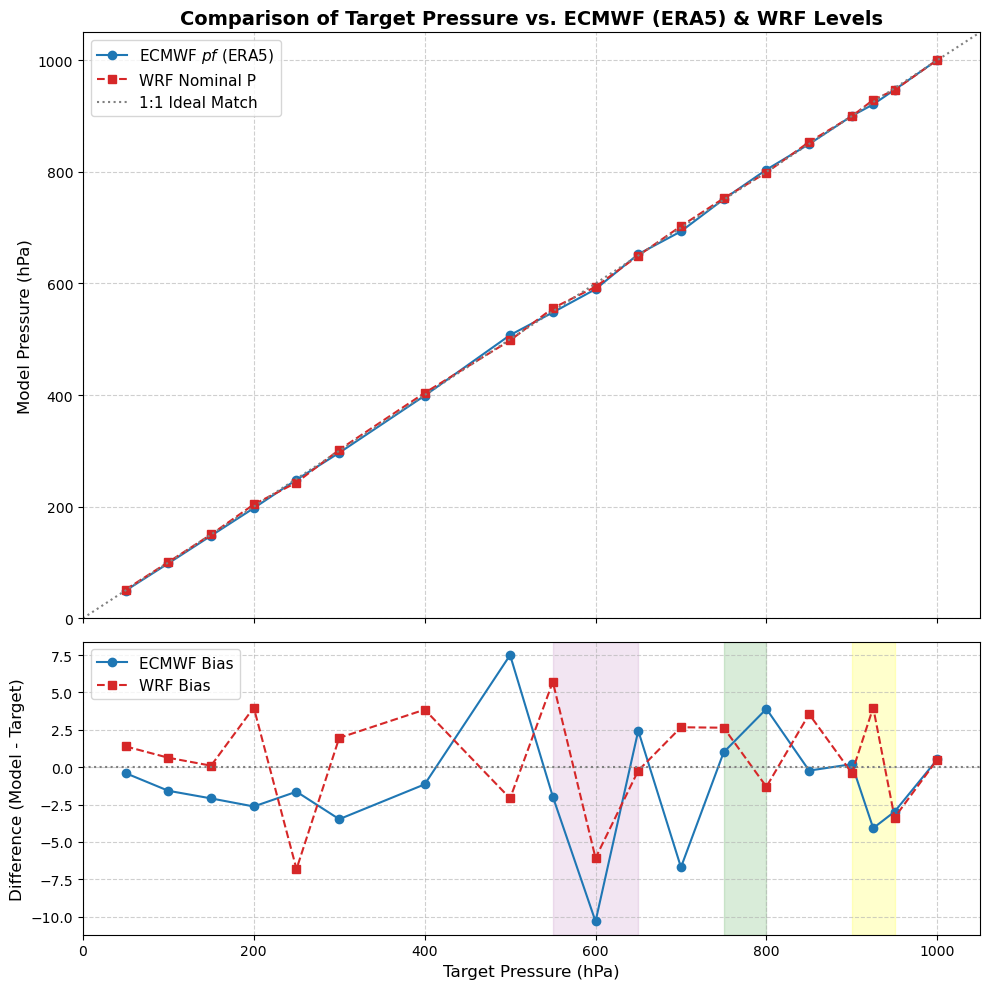

In [ ]:
# 1. Input Data from the table
target_p = np.array([50, 100, 150, 200, 250, 300, 400, 500, 550, 600, 650, 700, 750, 800, 850, 900, 925, 950, 1000])
ecmwf_pf = np.array([49.60, 98.42, 147.91, 197.37, 248.36, 296.52, 398.85, 507.50, 548.03, 589.68, 652.44, 693.30, 751.00, 803.90, 849.77, 900.20, 920.92, 947.02, 1000.52])
wrf_nom_p = np.array([51.39, 100.63, 150.10, 203.99, 243.18, 301.96, 403.85, 497.91, 555.71, 593.92, 649.77, 702.67, 752.64, 798.69, 853.55, 899.60, 928.99, 946.63, 1000.51])

# Calculate differences (Model - Target)
ecmwf_diff = ecmwf_pf - target_p
wrf_diff = wrf_nom_p - target_p

# 2. Setup the figure and axes (2 subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# --- TOP PANEL: Absolute Pressures ---
ax1.plot(target_p, ecmwf_pf, marker='o', linestyle='-', color='#1f77b4', label='ECMWF $pf$ (ERA5)')
ax1.plot(target_p, wrf_nom_p, marker='s', linestyle='--', color='#d62728', label='WRF Nominal P')

# Add a 1:1 reference line
ax1.plot([0, 1050], [0, 1050], color='gray', linestyle=':', label='1:1 Ideal Match')

ax1.set_title('Comparison of Target Pressure vs. ECMWF (ERA5) & WRF Levels', fontsize=14, fontweight='bold')
ax1.set_ylabel('Model Pressure (hPa)', fontsize=12)
ax1.set_xlim(0, 1050)
ax1.set_ylim(0, 1050)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# --- BOTTOM PANEL: Pressure Differences ---
ax2.plot(target_p, ecmwf_diff, marker='o', linestyle='-', color='#1f77b4', label='ECMWF Bias')
ax2.plot(target_p, wrf_diff, marker='s', linestyle='--', color='#d62728', label='WRF Bias')

# Add a 0-difference reference line
ax2.axhline(0, color='gray', linestyle=':')

ax2.set_xlabel('Target Pressure (hPa)', fontsize=12)
ax2.set_ylabel('Difference (Model - Target)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

# Highlight the AR critical zones on the bottom panel
ax2.axvspan(900, 950, color='yellow', alpha=0.2, label='LLJ Zone')
ax2.axvspan(750, 800, color='green', alpha=0.15, label='Melting Layer')
ax2.axvspan(550, 650, color='purple', alpha=0.1, label='Mid-Trop Gap')

# Clean up layout and display
plt.tight_layout()
plt.show()